In [ ]:
# 모듈 불러오기

import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import shap
import warnings
import platform
warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False



print("=" * 60)
print("로드 완료")
print("=" * 60)

In [ ]:
# 데이터 불러오기
df = pd.read_csv("ending_club_preprocessed2.csv", parse_dates=['issue_d', 'earliest_cr_line'])

C:\Users\Cho\AppData\Local\Temp\ipykernel_19384\288974645.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("ending_club_preprocessed2.csv", parse_dates=['issue_d', 'earliest_cr_line'])


In [ ]:
# 사용할 컬럼(use_col) 지정

use_col = [
    # ── 타겟 ──
    "target",                        # 부도 여부 (0/1)
    # ── 대출 기본 정보 ──
    "loan_amnt",                     # 대출 금액
    "term",                          # 기간 (36/60개월)
    "int_rate",                      # 이자율
    "sub_grade",                     # 등급 세분류 (A1~G5)
    "installment",                   # 월 상환액 ($)
    "purpose",                       # 대출 목적
    "issue_year",                    # 대출 실행 연도
    # ── 차입자 정보 ──
    "emp_length",                    # 근속 연수
    "home_ownership",                # 주거 형태
    "annual_inc",                    # 자기보고 연소득 ($)
    # ── 부채 관련 지표 ──
    "dti",                           # 부채 대비 소득 비율
    "fico_mid",                      # FICO 점수 평균
    "pub_rec",                       # 공공 부정 기록 건수
    # ── 계좌 잔액 / 한도 ──
    "avg_cur_bal",                   # 전체 계좌 평균 잔액 ($)
    "revol_bal",                     # 리볼빙 총 잔액 ($)
    "revol_util",                    # 리볼빙 이용률 (%)
    "total_rev_hi_lim",              # 전체 리볼빙 신용 한도 ($)
    "bc_open_to_buy",                # 뱅크카드 잔여 한도 ($)
    "total_bc_limit",                # 뱅크카드 총 한도 ($)
    "tot_hi_cred_lim",               # 전체 계좌 신용한도 합계 ($)
    # ── 계좌 수량 ──
    "num_actv_bc_tl",                # 활성 뱅크카드 수
    "num_actv_rev_tl",               # 활성 리볼빙 계좌 수
    "num_rev_tl_bal_gt_0",           # 잔액 > 0인 리볼빙 계좌 수
    "num_il_tl",                     # 할부 계좌 수
    "total_acc",                     # 전체 신용 계좌 수
    "acc_open_past_24mths",          # 최근 24개월 신규 계좌 수
    # ── 계좌 경과 기간 ──
    "mo_sin_old_rev_tl_op",          # 가장 오래된 리볼빙 계좌 경과 월수
    "mo_sin_rcnt_rev_tl_op",         # 가장 최근 리볼빙 계좌 경과 월수
    "mo_sin_old_il_acct",            # 가장 오래된 할부 계좌 경과 월수
    "mths_since_recent_bc",          # 최근 뱅크카드 개설 경과 월수
    "mths_since_recent_inq",         # 최근 신용 조회 경과 월수
    "mths_since_rcnt_il",            # 최근 할부 계좌 경과 월수 1
    # ── 연체 경과 (mths_since 계열) ──
    "mths_since_last_delinq",        # 마지막 연체 경과 월수 1
    "mths_since_last_major_derog",   # 마지막 주요 부정 기록 경과 월수 1
    "mths_since_recent_revol_delinq",# 최근 리볼빙 연체 경과 월수
    "mths_since_recent_bc_dlq",      # 최근 뱅크카드 연체 경과 월수 1
    # ── 연체 이력 지표 ──
    "pct_tl_nvr_dlq",                # 연체 없는 계좌 비율 (%)
    # ── 파생 플래그 ──
    "mths_since_last_major_derog_flag", #  마지막 주요 부정 기록 경과 (Y/N)1 
    "mths_since_recent_inq_flag" ,  # 가장 최근 신용 조회 이후 경과 월수 (Y/N)1 
		"issue_d", "earliest_cr_line",
]

# 중복 검증
df = df[use_col].copy()

In [ ]:
# 파생컬럼 

# 대출 승인 날짜: 년, 월 분리
df['issue_year'] = df['issue_d'].dt.year.astype(str)
df['issue_month'] = df['issue_d'].dt.month.astype(str)

# 신용계좌 개설 날짜 : 년 단위 컬럼 생성
df["earliest_cr_line_year"]= pd.to_datetime(df["earliest_cr_line"]).dt.year.astype(str)

# 월 상환 부담율(installment_to_income) 생성 
df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12)

# 대출규모 대비 소득(loan_to_income) 생성
df['loan_to_income'] = df['loan_amnt'] / df['annual_inc'] 

# 회전부채 대비 소득(revol_bal_to_income) 생성
df['revol_bal_to_income'] = df['revol_bal'] / df['annual_inc'] #  revol_bal_to_income (회전부채 대비 소득)

# 숫자 잘못 처리 되었을 때 NaN 처리
new_cols = ['installment_to_income', 'loan_to_income','revol_bal_to_income']
for col in new_cols:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)

# 생성후 Drop / "annual_inc", "revol_bal","installment" 
df = df.drop(columns=["issue_d", "earliest_cr_line", "annual_inc", "revol_bal","installment"])



print(f"전체: {len(df.columns)}")
print(f"고유: {len(set(df.columns))}") # >> 42 정상

전체: 42
고유: 42


## 통계검정 시작

In [ ]:
# 통계검정 작업용 데이터셋 생성
df2 = df.copy()

In [ ]:
# X, y 분리

y = df2["target"]
X = df2.drop(columns=["target"])

# 4) train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [8]:
# 파생변수 결측값 채우기(★train/test 이후 결측값 채우기)
new_cols = ['installment_to_income', 'loan_to_income', 'revol_bal_to_income']
for col in new_cols:
    train_median = X_train[col].median()                    # train으로만 계산
    X_train[col] = X_train[col].fillna(train_median)       # train에 적용
    X_test[col] = X_test[col].fillna(train_median)         # test에도 train median 사용

## mo_sin_old_il_acct  가장 오래된 할부 계좌 이후 경과 월수
## 0 으로 
X_train["mo_sin_old_il_acct"] = X_train["mo_sin_old_il_acct"].fillna(0) 
X_test["mo_sin_old_il_acct"] =  X_test["mo_sin_old_il_acct"].fillna(0) 


# mths_since_rcnt_il 가장 최근 할부 계좌(Installment Loan) 개설 이후 경과 월수
## 중앙값으로 채우기 
medi_rcnt_il = X_train["mths_since_rcnt_il"].median()
X_train["mths_since_rcnt_il"] = X_train["mths_since_rcnt_il"].fillna(medi_rcnt_il)
X_test["mths_since_rcnt_il"] = X_test["mths_since_rcnt_il"].fillna(medi_rcnt_il)

# ★train/test 이후 전처리
# dti "sub_grade" 사용해야함 
X_train["dti"] = X_train.groupby("sub_grade")["dti"].transform(lambda x: x.fillna(x.median())
)
train_dit_medi = X_train.groupby("sub_grade")["dti"].median()
X_test["dti"] = X_test["dti"].fillna(X_test["sub_grade"].map(train_dit_medi))

# 신용 조회, 
cols = [
'mths_since_last_delinq',
'mths_since_last_major_derog',
'mths_since_recent_revol_delinq',
'mths_since_recent_bc_dlq',
'mths_since_recent_inq',
'mths_since_recent_bc'
]
for col in cols:
    max_val = X_train[col].max()
    X_train[col] = X_train[col].fillna(max_val + 1)
    X_test[col] = X_test[col].fillna(max_val + 1)
    
# pct_tl_nvr_dlq 연체 이력이 한 번도 없는 계좌 비율 (%)
## 중앙값으로 채우기 
medi_dlq = X_train["pct_tl_nvr_dlq"].median()
X_train["pct_tl_nvr_dlq"] = X_train["pct_tl_nvr_dlq"].fillna(medi_dlq)
X_test["pct_tl_nvr_dlq"] = X_test["pct_tl_nvr_dlq"].fillna(medi_dlq)

In [9]:
#결측치 최종 검증(값 있는지 확인)
print(X_train.isna().sum().sort_values(ascending = False).head(5))
print(X_test.isna().sum().sort_values(ascending = False).head(5))


loan_amnt    0
term         0
int_rate     0
sub_grade    0
purpose      0
dtype: int64
loan_amnt    0
term         0
int_rate     0
sub_grade    0
purpose      0
dtype: int64


📌 변수: dti

[Step 1] 기술통계
  정상(0) - 평균: 17.9924 | 중앙값: 17.3000 | std: 9.7903
  부도(1) - 평균: 20.3103 | 중앙값: 19.9500 | std: 10.3717


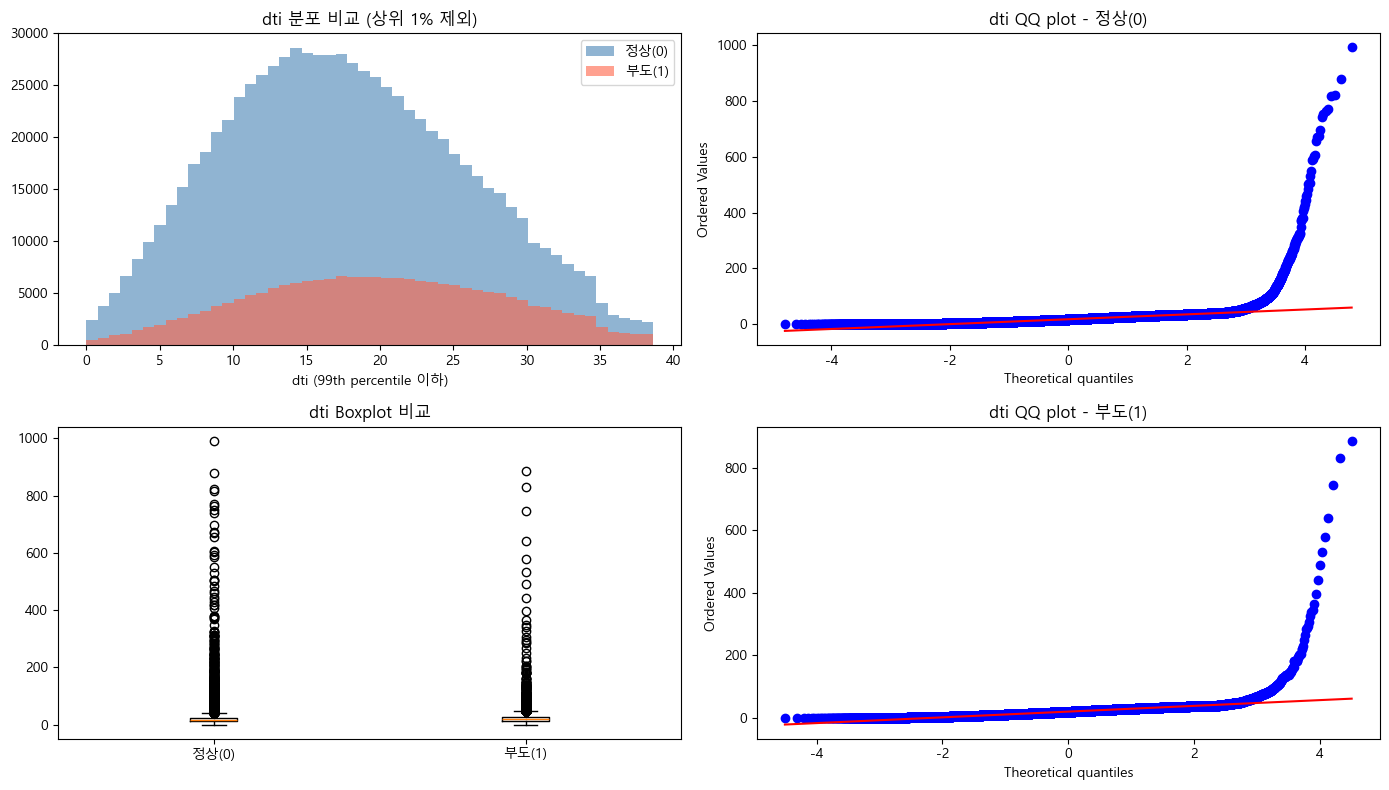


[Step 2] 정규성 검정
  Shapiro-Wilk (참고용, n=5000 샘플링)
  정상(0): statistic=0.9339, p=0.0000
  부도(1): statistic=0.9106, p=0.0000
  ※ 대용량 데이터 → QQ plot 시각적 판단을 우선으로 할 것

[Step 3] Mann-Whitney U 검정
  U statistic: 71437554262.0000
  p-value: 0.0000 → 유의미한 차이 ✅

[Step 4] 효과 크기 (rank-biserial correlation)
  r = 0.1522 → 작은 효과 
📌 변수: loan_to_income

[Step 1] 기술통계
  정상(0) - 평균: 0.4125 | 중앙값: 0.1905 | std: 75.8821
  부도(1) - 평균: 0.3019 | 중앙값: 0.2381 | std: 18.3839


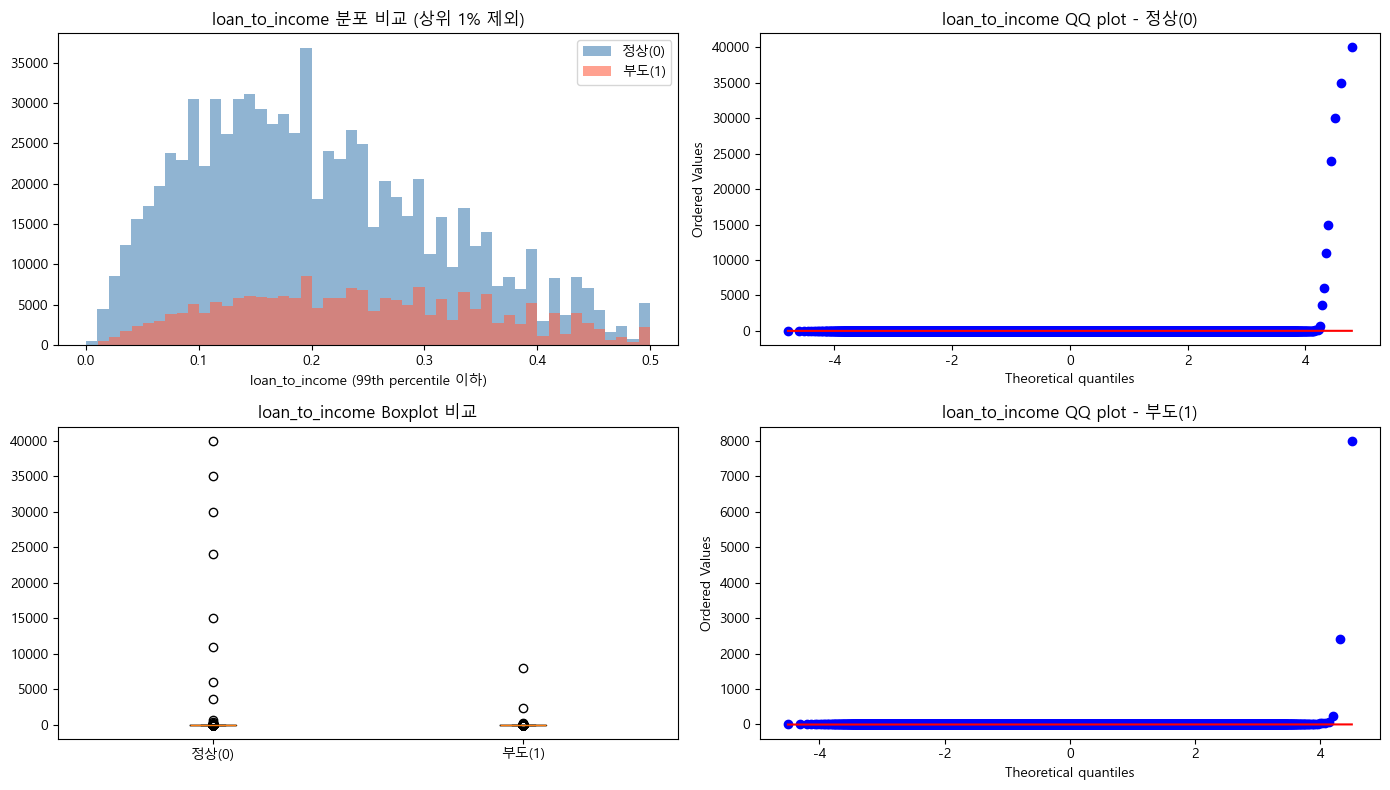


[Step 2] 정규성 검정
  Shapiro-Wilk (참고용, n=5000 샘플링)
  정상(0): statistic=0.8423, p=0.0000
  부도(1): statistic=0.6360, p=0.0000
  ※ 대용량 데이터 → QQ plot 시각적 판단을 우선으로 할 것

[Step 3] Mann-Whitney U 검정
  U statistic: 67679365005.5000
  p-value: 0.0000 → 유의미한 차이 ✅

[Step 4] 효과 크기 (rank-biserial correlation)
  r = 0.1968 → 작은 효과 


In [ ]:
# ── 검정용 데이터 준비 (train 기준) ──────────────────────
train_df = X_train.copy()
train_df["target"] = y_train.values

target_cols = ["dti", "loan_to_income"]

for col in target_cols:
    group0 = train_df[train_df["target"] == 0][col].dropna()  # 정상
    group1 = train_df[train_df["target"] == 1][col].dropna()  # 부도

    print("=" * 60)
    print(f"📌 변수: {col}")
    print("=" * 60)

    # ── Step 1. 기술통계 ─────────────────────────────────
    print("\n[Step 1] 기술통계")
    print(f"  정상(0) - 평균: {group0.mean():.4f} | 중앙값: {group0.median():.4f} | std: {group0.std():.4f}")
    print(f"  부도(1) - 평균: {group1.mean():.4f} | 중앙값: {group1.median():.4f} | std: {group1.std():.4f}")

    # ── Step 2. 정규성 시각화 (히스토그램 + QQ plot) ──────
    fig = plt.figure(figsize=(14, 8))
    gs = gridspec.GridSpec(2, 2)

    # 히스토그램
    ax1 = fig.add_subplot(gs[0, 0])

    # 이상치 제거 후 시각화 (99 percentile 기준)
    p99 = np.percentile(pd.concat([group0, group1]), 99)
    g0_clipped = group0[group0 <= p99]
    g1_clipped = group1[group1 <= p99]

    ax1.hist(g0_clipped, bins=50, alpha=0.6, color="steelblue", label="정상(0)")
    ax1.hist(g1_clipped, bins=50, alpha=0.6, color="tomato", label="부도(1)")
    ax1.set_title(f"{col} 분포 비교 (상위 1% 제외)")
    ax1.set_xlabel(f"{col} (99th percentile 이하)")
    ax1.legend()

    # QQ plot - 정상
    ax2 = fig.add_subplot(gs[0, 1])
    stats.probplot(group0, dist="norm", plot=ax2)
    ax2.set_title(f"{col} QQ plot - 정상(0)")

    # QQ plot - 부도
    ax3 = fig.add_subplot(gs[1, 1])
    stats.probplot(group1, dist="norm", plot=ax3)
    ax3.set_title(f"{col} QQ plot - 부도(1)")

    # Boxplot
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.boxplot([group0, group1], labels=["정상(0)", "부도(1)"])
    ax4.set_title(f"{col} Boxplot 비교")

    plt.tight_layout()
    plt.show()

    # ── Step 3. 정규성 검정 (shaprio 검정) ────   
    print("\n[Step 2] 정규성 검정")
    sample_size = min(5000, len(group0), len(group1))

    sw0 = stats.shapiro(group0.sample(sample_size, random_state=42))
    sw1 = stats.shapiro(group1.sample(sample_size, random_state=42))
    print(f"  Shapiro-Wilk (참고용, n={sample_size} 샘플링)")
    print(f"  정상(0): statistic={sw0.statistic:.4f}, p={sw0.pvalue:.4f}")
    print(f"  부도(1): statistic={sw1.statistic:.4f}, p={sw1.pvalue:.4f}")
    print(f"  ※ 대용량 데이터 → QQ plot 시각적 판단을 우선으로 할 것")

    # ── Step 4. 본 검정 (Mann-Whitney U) ─────────────────
    print("\n[Step 3] Mann-Whitney U 검정")
    u_stat, p_val = stats.mannwhitneyu(group0, group1, alternative="two-sided")
    print(f"  U statistic: {u_stat:.4f}")
    print(f"  p-value: {p_val:.4f} → {'유의미한 차이 ✅' if p_val < 0.05 else '차이 없음 ❌'}")

    # ── Step 5. 효과 크기 (rank-biserial correlation) ────
    print("\n[Step 4] 효과 크기 (rank-biserial correlation)")
    n0, n1 = len(group0), len(group1)
    r = 1 - (2 * u_stat) / (n0 * n1)
    print(f"  r = {r:.4f}", end=" → ")
    if abs(r) < 0.1:
        print("효과 없음")
    elif abs(r) < 0.3:
        print("작은 효과 ")
    elif abs(r) < 0.5:
        print("중간 효과 ")
    else:
        print("큰 효과 ")


### 결과 해석 흐름

# 기술통계 → 두 그룹 평균/중앙값 차이 확인
#     ↓
# 히스토그램/QQ plot → 비정규 분포 확인
#     ↓
# KS test → p < 0.05 → 비정규 확정
#     ↓
# Mann-Whitney U → p < 0.05 → 부도/정상 그룹 간 유의미한 차이
#     ↓
# 효과 크기 → 실질적으로 얼마나 차이나는지

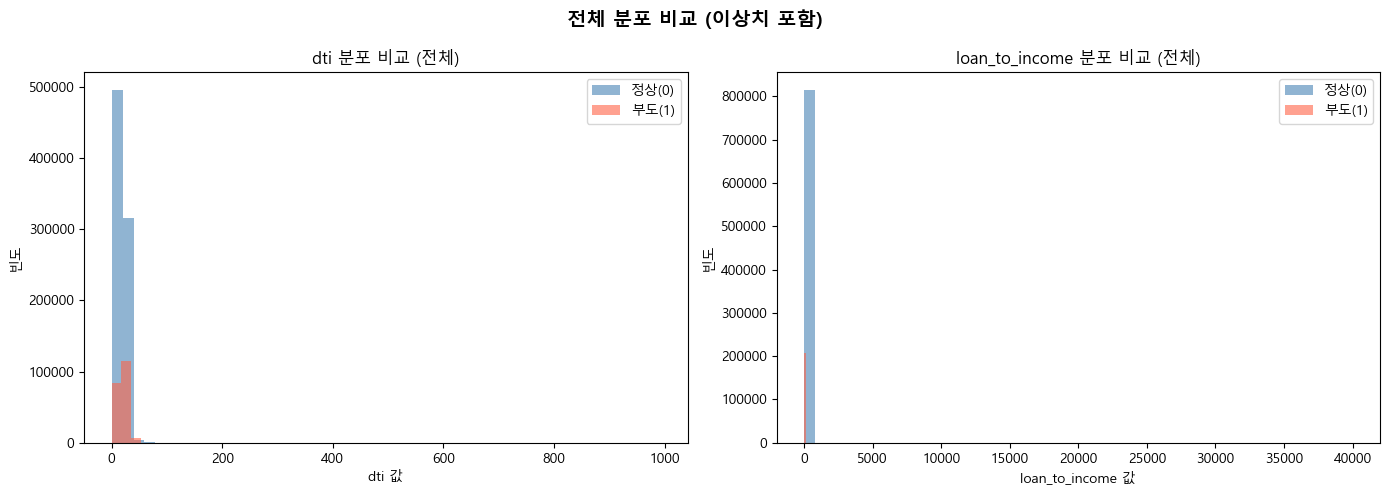

In [ ]:
# 변수별 분포 비교 그래프

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_cols = ["dti", "loan_to_income"]

for ax, col in zip(axes, target_cols):
    group0 = train_df[train_df["target"] == 0][col].dropna()
    group1 = train_df[train_df["target"] == 1][col].dropna()

    ax.hist(group0, bins=50, alpha=0.6, color="steelblue", label="정상(0)")
    ax.hist(group1, bins=50, alpha=0.6, color="tomato", label="부도(1)")
    ax.set_title(f"{col} 분포 비교 (전체)")
    ax.set_xlabel(f"{col} 값")
    ax.set_ylabel("빈도")
    ax.legend()

plt.suptitle("전체 분포 비교 (이상치 포함)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()